In [1]:
import matplotlib.pyplot as plt
import json
from common import *

data_file = open("./results.json", "r")

data = json.load(data_file)

# Temps en fonction du nombre d'élément pour chacune des approche
times = []

## Method 1 (Sequential)
times.append([(dt["size"],dt["time"]) for dt in data["0"]])

## Parallel methods
for i in range(1, 4):
    times.append([(dt["size"],dt["time"]) for dt in filter(lambda dt: dt["nbT"] == 8, data[str(i)])])


# tries en fonction du nombre d'éléments
for i in range(len(times)):
    times[i].sort(key = lambda s_t : s_t[0])
    times[i] = list(map(lambda s_t:  s_t[1], times[i]))



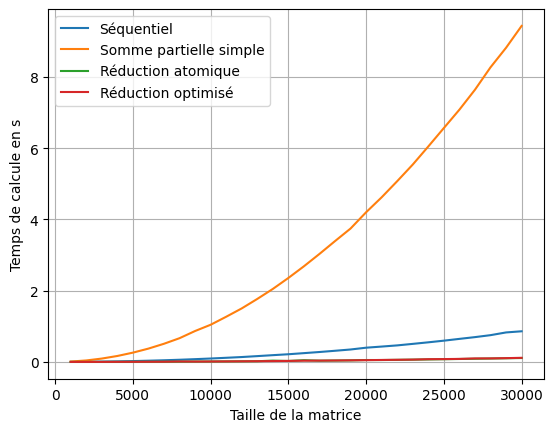

In [2]:

for i in range(len(times)):
    plt.plot(TEST_SIZE,times[i], label=METHODS_NAMES[i])
plt.xlabel("Taille de la matrice")
plt.ylabel("Temps de calcule en s")
# plt.title("Temps pris par chaque implémentation (au nombre maximum de thread).")
plt.legend()
plt.grid(True)

plt.savefig("./images/impl_comp.svg")
plt.show()


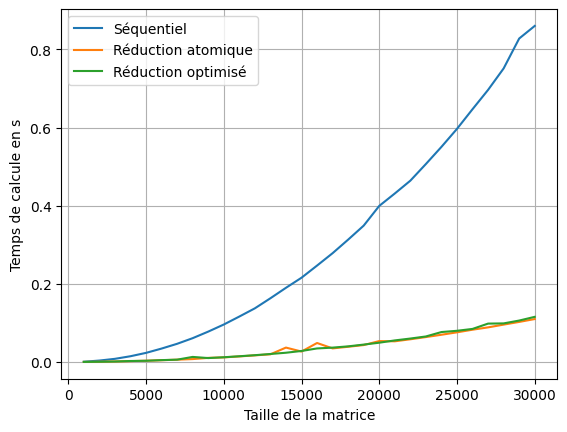

In [3]:
for i in [0,2,3]:
    plt.plot(TEST_SIZE,times[i], label=METHODS_NAMES[i])

plt.xlabel("Taille de la matrice")
plt.ylabel("Temps de calcule en s")
# plt.title("Temps pris par des implémentations (au nombre maximum de thread).")
plt.legend()
plt.grid(True)

plt.savefig("./images/impl_comp2.svg")
plt.show()


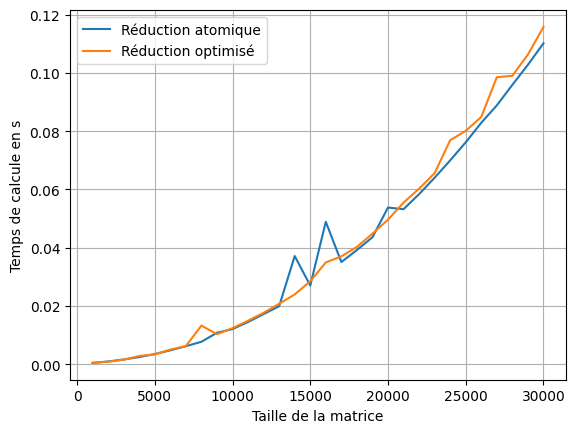

In [4]:
for i in [2,3]:
    plt.plot(TEST_SIZE,times[i], label=METHODS_NAMES[i])

plt.xlabel("Taille de la matrice")
plt.ylabel("Temps de calcule en s")
# plt.title("Temps pris par des implémentations (au nombre maximum de thread).")
plt.legend()
plt.grid(True)

plt.savefig("./images/impl_comp3.svg")
plt.show()

In [5]:
# 2eme methode

simple_reduc_dt = data["1"]
times_simple_reduc = []

for i in range(2, 9):
    times_simple_reduc.append(
        [(dt["size"], dt["time"]) for dt in filter(lambda dt: dt["nbT"] == i, simple_reduc_dt)]
    )
    times_simple_reduc[-1].sort(key=lambda s_t: s_t[0])
    times_simple_reduc[-1] = list(map(lambda s_t: s_t[1], times_simple_reduc[-1]))


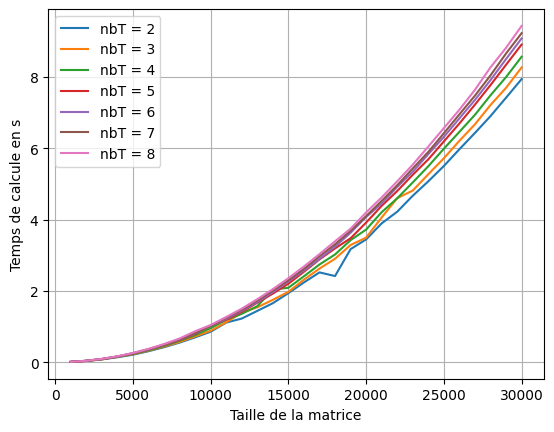

In [6]:
for i in range(0,7):
    plt.plot(TEST_SIZE, times_simple_reduc[i], label=f"nbT = {i+2}")

plt.xlabel("Taille de la matrice")
plt.ylabel("Temps de calcule en s")
# plt.title("Temps pris par l'implémentation \"réduction simple\" en fonction du nombre de thread.")
plt.legend()
plt.grid(True)

plt.savefig("./images/simple_reduc_times.svg")
plt.show()


In [7]:
max_size_times_simple_reduc = [time[-1] for time in times_simple_reduc]

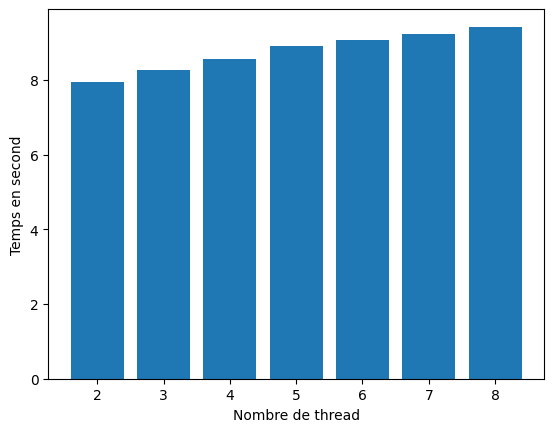

In [8]:
plt.bar(range(2,9), max_size_times_simple_reduc, label="_ignore")
plt.xlabel("Nombre de thread")
plt.ylabel("Temps en second")
# plt.title(f"Temps pris par l'implémentation \"réduction simple\" en fonction du nombre de thread pour {TEST_SIZE[-1]} éléments.")

plt.savefig("./images/max_simpl_reduc_times.svg")
plt.show()


In [9]:
# 3 eme methode

atomic_reduc_dt = data["2"]
times_atomic_reduc = []

for i in range(2, 9):
    times_atomic_reduc.append(
        [(dt["size"], dt["time"]) for dt in filter(lambda dt: dt["nbT"] == i, atomic_reduc_dt)]
    )
    times_atomic_reduc[-1].sort(key=lambda s_t: s_t[0])
    times_atomic_reduc[-1] = list(map(lambda s_t: s_t[1], times_atomic_reduc[-1]))

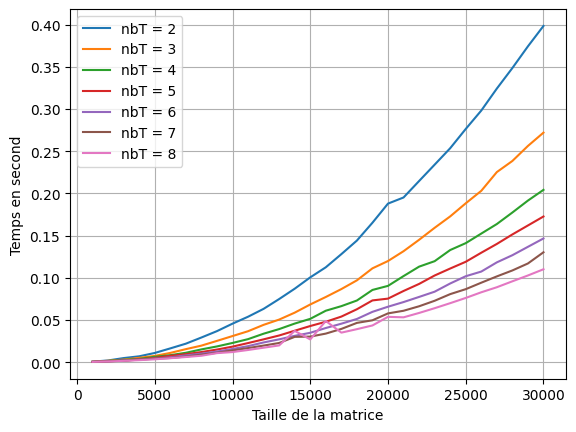

In [10]:
for i in range(0,7):
    plt.plot(TEST_SIZE, times_atomic_reduc[i], label=f"nbT = {i+2}")

plt.xlabel("Taille de la matrice")
plt.ylabel("Temps en second")
plt.legend()
plt.grid(True)

plt.savefig("./images/atomic_reduc_times.svg")
plt.show()


In [11]:
max_size_times_atomic_reduc = [time[-1] for time in times_atomic_reduc]

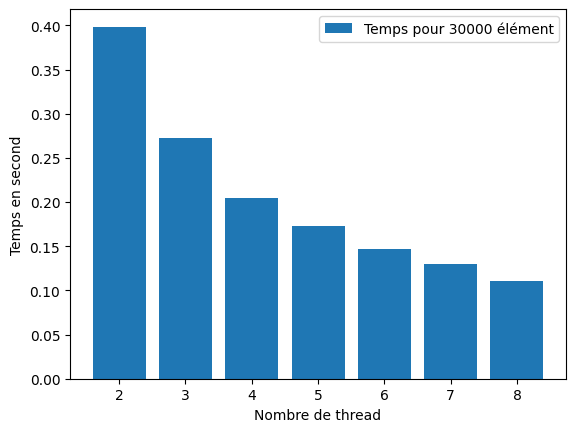

In [12]:
plt.bar(range(2,9), max_size_times_atomic_reduc, label=f"Temps pour {TEST_SIZE[-1]} élément")
plt.xlabel("Nombre de thread")
plt.ylabel("Temps en second")
plt.legend()

plt.savefig("./images/max_atomic_reduc_times.svg")
plt.show()

In [13]:
# 4 eme methode

opti_reduc_dt = data["3"]
times_opti_reduc = []

for i in range(2, 9):
    times_opti_reduc.append(
        [(dt["size"], dt["time"]) for dt in filter(lambda dt: dt["nbT"] == i, opti_reduc_dt)]
    )
    times_opti_reduc[-1].sort(key=lambda s_t: s_t[0])
    times_opti_reduc[-1] = list(map(lambda s_t: s_t[1], times_opti_reduc[-1]))


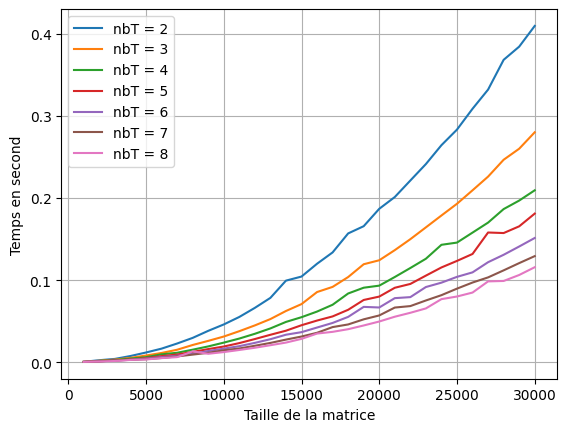

In [14]:
for i in range(0,7):
    plt.plot(TEST_SIZE, times_opti_reduc[i], label=f"nbT = {i+2}")

plt.xlabel("Taille de la matrice")
plt.ylabel("Temps en second")
plt.legend()
plt.grid(True)

plt.savefig("./images/opti_reduc_times.svg")
plt.show()


In [15]:
max_size_times_opti_reduc = [time[-1] for time in times_opti_reduc]

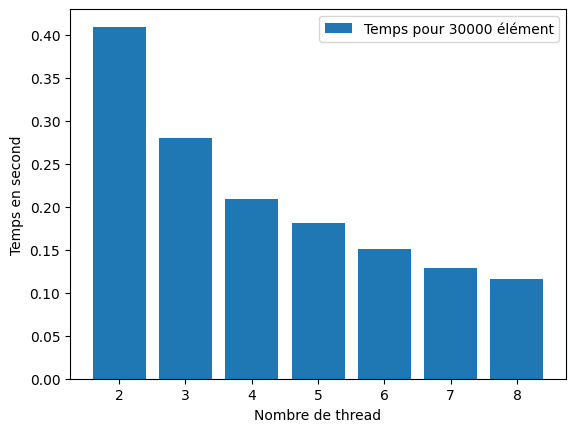

In [16]:
plt.bar(range(2,9), max_size_times_opti_reduc, label=f"Temps pour {TEST_SIZE[-1]} élément")
plt.xlabel("Nombre de thread")
plt.ylabel("Temps en second")
plt.legend()

plt.savefig("./images/max_opti_reduc_times.svg")
plt.show()